In [1]:
# ==============================================================================
# Cell 1: 建立 my_utils.py (解決 macOS 多核心 Multiprocessing 錯誤)
# ==============================================================================
import os

utils_code = """
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from transformers import BertModel

# --- 1. 資料集類別 (針對 Title + Content 優化) ---
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        # 確保轉為字串
        text = str(self.texts[item])
        
        # Tokenization
        enc = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        
        return {
            'input_ids': enc['input_ids'].flatten(),
            'attention_mask': enc['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[item], dtype=torch.long)
        }

# --- 2. 推論用資料集 (無標籤) ---
class InferenceDataset(Dataset):
    def __init__(self, texts, tokenizer, max_len):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = str(self.texts[item])
        enc = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        return {
            'input_ids': enc['input_ids'].flatten(),
            'attention_mask': enc['attention_mask'].flatten()
        }

# --- 3. 通用 BERT 分類模型 ---
class BertClassifier(nn.Module):
    def __init__(self, model_name, num_classes):
        super(BertClassifier, self).__init__()
        self.bert = BertModel.from_pretrained(model_name)
        self.drop = nn.Dropout(p=0.3)
        self.out = nn.Linear(self.bert.config.hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.pooler_output
        output = self.drop(pooled_output)
        return self.out(output)

# --- 4. Focal Loss (解決類別不平衡) ---
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        else:
            return focal_loss.sum()
"""

with open("my_utils.py", "w", encoding="utf-8") as f:
    f.write(utils_code)

print("✅ 成功建立 my_utils.py！現在可以開啟 num_workers 進行多核訓練了。")

✅ 成功建立 my_utils.py！現在可以開啟 num_workers 進行多核訓練了。


In [2]:
# ==============================================================================
# Phase 1: 訓練 Reader Emotion 模型 (M4 Pro Full Core)
# ⚠️ 執行完請重啟 Kernel
# ==============================================================================
import os
# [安全設定] 限制 MPS 記憶體緩存，避免 GPU 記憶體溢出
os.environ['PYTORCH_MPS_HIGH_WATERMARK_RATIO'] = '0.0'
# [加速設定] 關閉 Tokenizer 的平行化警告
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import pandas as pd
import numpy as np
import torch
from torch.utils.data import DataLoader
from torch.optim import AdamW
from transformers import BertTokenizer, get_linear_schedule_with_warmup
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import f1_score, classification_report
from sklearn.preprocessing import LabelEncoder
from tqdm.auto import tqdm
import joblib
import gc
import multiprocessing

# 🔥 從剛剛建立的檔案匯入 (解決 Multiprocessing 錯誤)
from my_utils import TextDataset, BertClassifier, FocalLoss

# --- M4 Pro Config ---
MODEL_NAME = "hfl/chinese-roberta-wwm-ext-large"
MAX_LEN = 256
BATCH_SIZE = 8       # Batch 小一點以防爆顯存
ACCUM_STEPS = 4      # 梯度累積，等效 Batch = 32
EPOCHS = 3
LR = 2e-5
N_SPLITS = 5
# 🔥 全核心設定：M4 Pro 建議設 4~8，設太多反而會有 Process overhead
NUM_WORKERS = min(multiprocessing.cpu_count(), 8) 
DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

print(f"🚀 [Phase 1] 啟動 Emotion Training (Full Core Mode)")
print(f"   - Device: {DEVICE}")
print(f"   - CPU Workers: {NUM_WORKERS}")

# 1. 資料準備
try:
    df1 = pd.read_csv('TrainingData.csv')
    df2 = pd.read_csv('TestingData.csv')
    if 'label' not in df1.columns: df1.columns = ['label', 'title', 'content']
    if 'label' not in df2.columns: df2.columns = ['label', 'title', 'content']
    
    df_all = pd.concat([df1, df2], axis=0).dropna().reset_index(drop=True)
    # 組合 Title + Content
    df_all['text_input'] = df_all['title'].astype(str) + " [SEP] " + df_all['content'].astype(str).str[:300]
    
    print(f"✅ 資料載入: {len(df_all)} 筆")
except Exception as e:
    print(f"❌ 讀檔錯誤: {e}"); raise SystemExit

le = LabelEncoder()
df_all['label_idx'] = le.fit_transform(df_all['label'])
num_classes = len(le.classes_)

# 80/20 切分
X_train_80, X_test_20, y_train_80, y_test_20 = train_test_split(
    df_all['text_input'].values, df_all['label_idx'].values, 
    test_size=0.2, random_state=42, stratify=df_all['label_idx']
)

# 2. 5-Fold 訓練
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
best_val_f1 = 0

print(f"\n🔄 開始 5-Fold CV 訓練...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_80, y_train_80)):
    print(f"   🌟 Fold {fold+1}/{N_SPLITS}")
    
    # 建立 Dataset (使用外部檔案定義的 Class)
    train_ds = TextDataset(X_train_80[train_idx], y_train_80[train_idx], tokenizer, MAX_LEN)
    val_ds = TextDataset(X_train_80[val_idx], y_train_80[val_idx], tokenizer, MAX_LEN)
    
    # 🔥 DataLoader 開啟 pin_memory (加速 CPU->GPU 傳輸)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
    
    model = BertClassifier(MODEL_NAME, num_classes).to(DEVICE)
    optimizer = AdamW(model.parameters(), lr=LR)
    scheduler = get_linear_schedule_with_warmup(optimizer, int(len(train_loader)*EPOCHS/ACCUM_STEPS*0.1), len(train_loader)*EPOCHS/ACCUM_STEPS)
    criterion = FocalLoss()
    
    for epoch in range(EPOCHS):
        model.train()
        # tqdm 顯示進度
        loop = tqdm(train_loader, leave=False, desc=f"Ep {epoch+1}")
        for i, batch in enumerate(loop):
            ids = batch['input_ids'].to(DEVICE)
            mask = batch['attention_mask'].to(DEVICE)
            lbls = batch['labels'].to(DEVICE)
            
            out = model(ids, mask)
            loss = criterion(out, lbls) / ACCUM_STEPS
            loss.backward()
            
            if (i+1) % ACCUM_STEPS == 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step(); scheduler.step(); optimizer.zero_grad()
                
        # Validation
        model.eval()
        preds, trues = [], []
        with torch.no_grad():
            for batch in val_loader:
                out = model(batch['input_ids'].to(DEVICE), batch['attention_mask'].to(DEVICE))
                preds.extend(torch.argmax(out, dim=1).cpu().numpy())
                trues.extend(batch['labels'].cpu().numpy())
        
        val_f1 = f1_score(trues, preds, average='weighted')
        print(f"      Val F1: {val_f1:.4f}")
        
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(), 'best_emotion_model.bin')
            
    # [安全機制] 釋放記憶體
    del model, optimizer, train_loader, val_loader
    torch.mps.empty_cache(); gc.collect()

# 3. 20% 最終測試
print("\n📝 20% 最終測試...")
model = BertClassifier(MODEL_NAME, num_classes).to(DEVICE)
model.load_state_dict(torch.load('best_emotion_model.bin'))
model.eval()

test_ds = TextDataset(X_test_20, y_test_20, tokenizer, MAX_LEN)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

preds, trues = [], []
with torch.no_grad():
    for batch in tqdm(test_loader):
        out = model(batch['input_ids'].to(DEVICE), batch['attention_mask'].to(DEVICE))
        preds.extend(torch.argmax(out, dim=1).cpu().numpy())
        trues.extend(batch['labels'].cpu().numpy())

print(classification_report(trues, preds, target_names=le.classes_))
joblib.dump(le, 'emotion_le.pkl')

print("✅ [Phase 1] 完成！請務必重啟 Kernel (Kernel -> Restart)。")

🚀 [Phase 1] 啟動 Emotion Training (Full Core Mode)
   - Device: mps
   - CPU Workers: 8
✅ 資料載入: 47249 筆

🔄 開始 5-Fold CV 訓練...
   🌟 Fold 1/5


/opt/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Ep 1:   0%|          | 0/3780 [00:13<?, ?it/s]

      Val F1: 0.7047


/opt/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


...

Ep 3:   0%|          | 0/3780 [00:15<?, ?it/s]

      Val F1: 0.7739

📝 20% 最終測試...


/opt/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


  0%|          | 0/1182 [00:16<?, ?it/s]

                  precision    recall  f1-score   support

      feel_angry       0.75      0.72      0.74      1265
     feel_boring       0.77      0.74      0.75       589
 feel_depressing       0.81      0.87      0.84       629
      feel_happy       0.71      0.69      0.70      1868
feel_informative       0.79      0.80      0.80      4051
        feel_odd       0.74      0.75      0.75       610
       feel_warm       0.78      0.89      0.83       334
    feel_worried       0.72      0.68      0.70       104

        accuracy                           0.77      9450
       macro avg       0.76      0.77      0.76      9450
    weighted avg       0.77      0.77      0.77      9450

✅ [Phase 1] 完成！請務必重啟 Kernel (Kernel -> Restart)。


In [2]:
# ==============================================================================
# Phase 2: 生成情緒特徵 (全核心推論)
# ⚠️ 執行完請重啟 Kernel
# ==============================================================================
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"
import pandas as pd
import numpy as np
import torch
from torch.utils.data import DataLoader
from transformers import BertTokenizer
import joblib
from tqdm.auto import tqdm
import multiprocessing
# 匯入自定義模組
from my_utils import InferenceDataset, BertClassifier

MODEL_NAME = "hfl/chinese-roberta-wwm-ext-large"
MAX_LEN = 256
BATCH_SIZE = 16 
NUM_WORKERS = min(multiprocessing.cpu_count(), 8)
DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

print(f"🚀 [Phase 2] 生成情緒特徵 (Device: {DEVICE})")

# 1. 讀取主資料
try:
    df_news = pd.read_csv('News_Data_cleaned.csv')
    if 'content_clean' not in df_news.columns:
        print("⚠️ 警告：找不到 'content_clean'，使用 'title_clean' 替代。")
        df_news['content_clean'] = df_news['title_clean']
    
    # 組合 Title + Content
    df_news['text_input'] = df_news['title_clean'].astype(str) + " [SEP] " + df_news['content_clean'].astype(str).str[:300]
    print(f"✅ 讀取主資料: {len(df_news)} 筆")
except:
    print("❌ 找不到 News_Data_cleaned.csv"); raise SystemExit

# 2. 載入模型
le = joblib.load('emotion_le.pkl')
num_classes = len(le.classes_)
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
model = BertClassifier(MODEL_NAME, num_classes).to(DEVICE)
model.load_state_dict(torch.load('best_emotion_model.bin', map_location=DEVICE))
model.eval()

# 3. 預測 (開啟 num_workers 加速)
dataset = InferenceDataset(df_news['text_input'].values, tokenizer, MAX_LEN)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

probs_all = []
print("🔮 開始推論...")
with torch.no_grad():
    for batch in tqdm(loader):
        out = model(batch['input_ids'].to(DEVICE), batch['attention_mask'].to(DEVICE))
        probs_all.append(torch.softmax(out, dim=1).cpu().numpy())

probs_all = np.concatenate(probs_all, axis=0)

# 4. 存檔
for i, emotion in enumerate(le.classes_):
    df_news[f'prob_{emotion}'] = probs_all[:, i]

df_news.to_csv('News_Data_with_Emotion_Features.csv', index=False, encoding='utf-8-sig')
print(f"✅ 完成！已儲存。請重啟 Kernel。")

🚀 [Phase 2] 生成情緒特徵 (Device: mps)
✅ 讀取主資料: 23527 筆
🔮 開始推論...


/opt/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


  0%|          | 0/1471 [00:13<?, ?it/s]

✅ 完成！已儲存。請重啟 Kernel。


In [1]:
# ==============================================================================
# Phase 3: MacBERT 5-Fold OOF (Virality Prediction - Full Core)
# ⚠️ 執行完請重啟 Kernel
# ==============================================================================
import os
# [加速設定] 關閉 Tokenizer 的平行化警告
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import pandas as pd
import numpy as np
import torch
import torch.nn as nn  # 🔥 [修正] 補上這行，解決 NameError
from torch.utils.data import DataLoader
from transformers import BertTokenizer
from torch.optim import AdamW
from sklearn.model_selection import StratifiedKFold, train_test_split
import gc
import multiprocessing

# 匯入自定義模組
from my_utils import TextDataset, BertClassifier

# --- Config ---
MODEL_NAME = "hfl/chinese-macbert-base"
MAX_LEN = 256
BATCH_SIZE = 8       # M4 Pro 記憶體安全設定
EPOCHS = 2
N_SPLITS = 5
# 全核心設定
NUM_WORKERS = min(multiprocessing.cpu_count(), 8)
DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

print(f"🚀 [Phase 3] MacBERT Virality (Device: {DEVICE})")

# 1. 資料準備與救援
# ------------------------------------------------------------------------------
# 讀取 Phase 2 產生的檔案 (含情緒特徵 + 完整文字)
try:
    df_main = pd.read_csv('News_Data_with_Emotion_Features.csv')
    print("✅ 讀取主資料集成功")
except:
    print("❌ 找不到 News_Data_with_Emotion_Features.csv，請先執行 Phase 2")
    raise SystemExit

# 讀取時間特徵資料 (News_Data_cleaned_2.csv)
if os.path.exists('News_Data_cleaned_2.csv'):
    df_time = pd.read_csv('News_Data_cleaned_2.csv')
    time_cols = ['title_clean', 'hour', 'is_prime_time', 'is_work_hour', 'is_weekend', 'viral_latency_hours', 'is_instant_viral']
    cols_to_use = [c for c in time_cols if c in df_time.columns]
    
    # 確保 Join Key 型態一致
    df_time['title_clean'] = df_time['title_clean'].astype(str)
    df_main['title_clean'] = df_main['title_clean'].astype(str)
    
    # Left Join: 保留 df_main 所有資料，缺時間的補 NaN
    df = pd.merge(df_main, df_time[cols_to_use], on='title_clean', how='left')
    print("✅ 資料合併完成 (Left Join)")
else:
    df = df_main
    print("⚠️ 未發現 News_Data_cleaned_2.csv，僅使用基本特徵。")

# 確保 text_input 存在
if 'text_input' not in df.columns:
    df['text_input'] = df['title_clean'].astype(str) + " [SEP] " + df['content'].astype(str).str[:200]

target_col = 'label'
text_col = 'text_input'

# 收集所有 Meta Features
emotion_cols = [c for c in df.columns if c.startswith('prob_')]
time_cols_no_title = [c for c in df.columns if c in ['hour', 'is_prime_time', 'viral_latency_hours', 'is_instant_viral']]
meta_cols = emotion_cols + time_cols_no_title

# 補結構特徵
if 'title_len' not in df.columns: df['title_len'] = df['title_clean'].apply(len)
if 'punct_count' not in df.columns: df['punct_count'] = df['title_clean'].apply(lambda x: x.count('!') + x.count('?'))
if 'has_digit' not in df.columns: df['has_digit'] = df['title_clean'].apply(lambda x: 1 if any(d.isdigit() for d in x) else 0)

meta_cols.extend(['title_len', 'punct_count', 'has_digit'])
# 去除重複並確認存在
meta_cols = [c for c in list(set(meta_cols)) if c in df.columns]

print(f"📝 Meta Features ({len(meta_cols)}): {meta_cols}")

# 2. 80/20 切分
# ------------------------------------------------------------------------------
X_full = df[text_col].values
y_full = df[target_col].values
meta_full = df[meta_cols].values

print("✂️ 執行 80/20 切分...")
X_train_80, X_test_20, y_train_80, y_test_20, meta_train_80, meta_test_20 = train_test_split(
    X_full, y_full, meta_full, test_size=0.2, random_state=42, stratify=y_full
)

# 3. 5-Fold OOF
# ------------------------------------------------------------------------------
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

oof_preds_80 = np.zeros(len(X_train_80))
test_preds_20_accum = np.zeros(len(X_test_20))

print(f"\n🔄 開始 5-Fold CV...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_80, y_train_80)):
    print(f"   🌟 Fold {fold+1}/{N_SPLITS}")
    
    # 建立 Dataset
    train_ds = TextDataset(X_train_80[train_idx], y_train_80[train_idx], tokenizer, MAX_LEN)
    val_ds = TextDataset(X_train_80[val_idx], y_train_80[val_idx], tokenizer, MAX_LEN)
    
    # DataLoader (開啟多核加速)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
    
    # 初始化模型
    model = BertClassifier(MODEL_NAME, 2).to(DEVICE)
    optimizer = AdamW(model.parameters(), lr=2e-5)
    loss_fn = nn.CrossEntropyLoss().to(DEVICE) # 現在 nn 已經定義了，不會報錯
    
    # 訓練迴圈
    for epoch in range(EPOCHS):
        model.train()
        for batch in train_loader:
            optimizer.zero_grad()
            ids = batch['input_ids'].to(DEVICE)
            mask = batch['attention_mask'].to(DEVICE)
            lbls = batch['labels'].to(DEVICE)
            
            # 使用自定義 BertClassifier 的 forward
            out = model(ids, mask) 
            loss = loss_fn(out, lbls)
            loss.backward()
            optimizer.step()
            
    # OOF 預測 (驗證集)
    model.eval()
    val_probs = []
    with torch.no_grad():
        for batch in val_loader:
            ids = batch['input_ids'].to(DEVICE)
            mask = batch['attention_mask'].to(DEVICE)
            out = model(ids, mask)
            # 取出 Label 1 的機率
            val_probs.extend(torch.softmax(out, dim=1)[:, 1].cpu().numpy())
    oof_preds_80[val_idx] = val_probs
    
    # 測試集預測 (累積平均)
    test_ds = TextDataset(X_test_20, y_test_20, tokenizer, MAX_LEN)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
    fold_test_probs = []
    with torch.no_grad():
        for batch in test_loader:
            ids = batch['input_ids'].to(DEVICE)
            mask = batch['attention_mask'].to(DEVICE)
            out = model(ids, mask)
            fold_test_probs.extend(torch.softmax(out, dim=1)[:, 1].cpu().numpy())
    test_preds_20_accum += np.array(fold_test_probs)
    
    # 釋放記憶體
    del model, optimizer, train_loader, val_loader, test_loader
    torch.mps.empty_cache()
    gc.collect()

test_preds_20_avg = test_preds_20_accum / N_SPLITS

# 4. 存檔中轉
# ------------------------------------------------------------------------------
print("\n💾 寫入中轉檔案...")
np.save('cache_L1_train.npy', oof_preds_80)
np.save('cache_L1_test.npy', test_preds_20_avg)
np.save('cache_y_train.npy', y_train_80)
np.save('cache_y_test.npy', y_test_20)
pd.DataFrame(meta_train_80, columns=meta_cols).to_pickle('cache_meta_train.pkl')
pd.DataFrame(meta_test_20, columns=meta_cols).to_pickle('cache_meta_test.pkl')

print("✅ [Phase 3] 完成！請務必重啟 Kernel。")

🚀 [Phase 3] MacBERT Virality (Device: mps)
✅ 讀取主資料集成功
✅ 資料合併完成 (Left Join)
📝 Meta Features (15): ['prob_feel_warm', 'hour', 'prob_feel_depressing', 'viral_latency_hours', 'prob_feel_boring', 'prob_feel_worried', 'prob_feel_happy', 'punct_count', 'prob_feel_informative', 'prob_feel_odd', 'prob_feel_angry', 'is_prime_time', 'has_digit', 'is_instant_viral', 'title_len']
✂️ 執行 80/20 切分...

🔄 開始 5-Fold CV...
   🌟 Fold 1/5


/opt/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


   🌟 Fold 2/5
   🌟 Fold 3/5
   🌟 Fold 4/5
   🌟 Fold 5/5

💾 寫入中轉檔案...
✅ [Phase 3] 完成！請務必重啟 Kernel。


🚀 [Phase 4] Stacking Final Run

🏆 實驗結果：語意優先 Stacking + 情緒特徵 (Full Core)
Best Threshold : 0.40
Accuracy       : 0.7198
Precision      : 0.6382
Recall         : 0.8967
F1-Score       : 0.7456
AUC            : 0.8168
------------------------------------------------------------
              precision    recall  f1-score   support

       一般(0)     0.8672    0.5703    0.6881      3675
       熱門(1)     0.6382    0.8967    0.7456      3106

    accuracy                         0.7198      6781
   macro avg     0.7527    0.7335    0.7169      6781
weighted avg     0.7623    0.7198    0.7145      6781



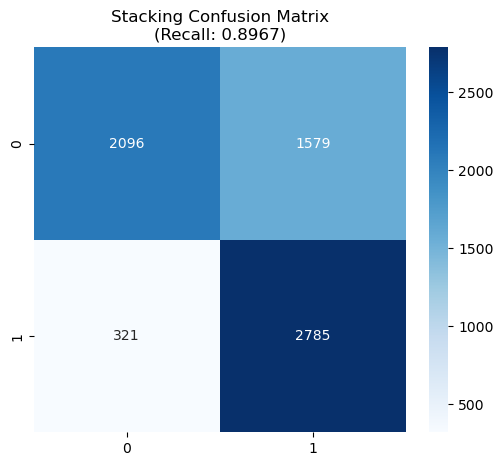

/var/folders/0z/fq8qk_1115166d_xt9zchp2r0000gn/T/ipykernel_34611/3833921250.py:69: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(result.importances[sorted_idx].T, vert=False, labels=X_test_meta.columns[sorted_idx])


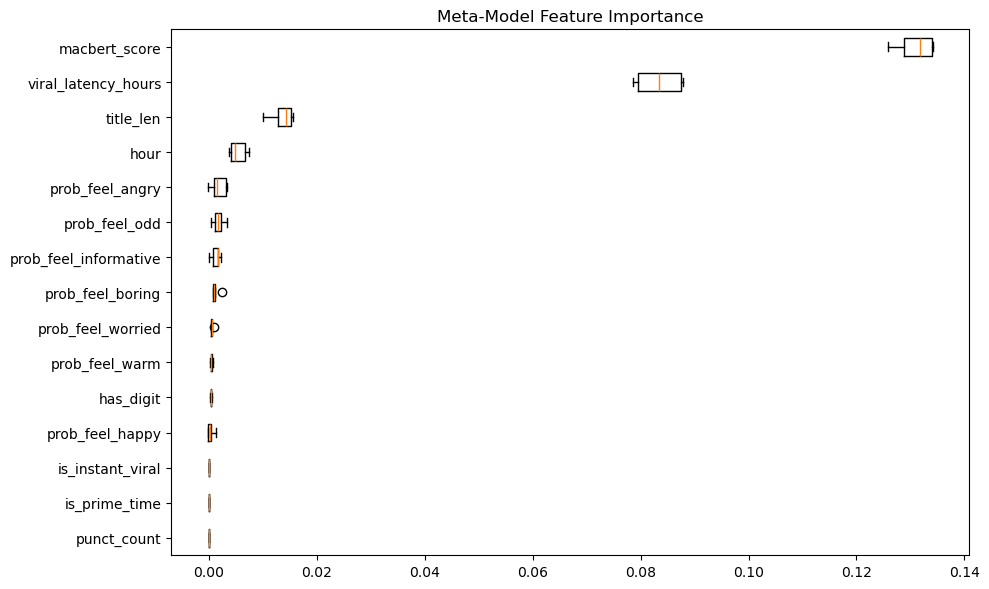

In [1]:
# ==============================================================================
# Phase 4: Stacking (無 GPU 需求)
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report, f1_score, accuracy_score, confusion_matrix, precision_score, recall_score, roc_auc_score
from sklearn.inspection import permutation_importance

print("🚀 [Phase 4] Stacking Final Run")

try:
    L1_train = np.load('cache_L1_train.npy')
    L1_test = np.load('cache_L1_test.npy')
    y_train = np.load('cache_y_train.npy')
    y_test = np.load('cache_y_test.npy')
    X_train_meta = pd.read_pickle('cache_meta_train.pkl')
    X_test_meta = pd.read_pickle('cache_meta_test.pkl')
except:
    print("❌ 找不到中轉檔"); raise SystemExit

X_train_meta['macbert_score'] = L1_train
X_test_meta['macbert_score'] = L1_test

for col in X_train_meta.columns:
    X_train_meta[col] = pd.to_numeric(X_train_meta[col], errors='coerce')
    X_test_meta[col] = pd.to_numeric(X_test_meta[col], errors='coerce')

# 訓練 (HistGradientBoosting 預設使用多核 CPU)
meta_model = HistGradientBoostingClassifier(
    learning_rate=0.03, max_iter=500, max_depth=6,
    l2_regularization=0.1, early_stopping=True,
    class_weight='balanced', random_state=42
)
meta_model.fit(X_train_meta, y_train)

# 測試
y_prob = meta_model.predict_proba(X_test_meta)[:, 1]
best_th, best_f1 = 0.5, 0
for th in np.arange(0.1, 0.9, 0.01):
    f1 = f1_score(y_test, (y_prob >= th).astype(int))
    if f1 > best_f1: best_f1, best_th = f1, th

y_pred = (y_prob >= best_th).astype(int)

# 報表
print("\n" + "="*60)
print(f"🏆 實驗結果：語意優先 Stacking + 情緒特徵 (Full Core)")
print("="*60)
print(f"Best Threshold : {best_th:.2f}")
print(f"Accuracy       : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision      : {precision_score(y_test, y_pred):.4f}")
print(f"Recall         : {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score       : {best_f1:.4f}")
print(f"AUC            : {roc_auc_score(y_test, y_prob):.4f}")
print("-" * 60)
print(classification_report(y_test, y_pred, target_names=['一般(0)', '熱門(1)'], digits=4))

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title(f'Stacking Confusion Matrix\n(Recall: {recall_score(y_test, y_pred):.4f})')
plt.show()

result = permutation_importance(meta_model, X_test_meta, y_test, n_repeats=5, random_state=42, n_jobs=-1)
sorted_idx = result.importances_mean.argsort()[-15:]
plt.figure(figsize=(10, 6))
plt.boxplot(result.importances[sorted_idx].T, vert=False, labels=X_test_meta.columns[sorted_idx])
plt.title("Meta-Model Feature Importance")
plt.tight_layout()
plt.show()